In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os
# Robust src path — works whether run manually or via papermill
_src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from config import *

df = pd.read_csv(f'{OUT_PATH}01_clean_sales.csv')
df['sale_date'] = pd.to_datetime(df['sale_date'])

print(f"Loaded: {len(df):,} rows")
print(f"Columns: {df.columns.tolist()}")

In [15]:
print(df.columns.tolist())

['year', 'month', 'Brand', 'Range', 'Size', 'Division', 'Material', 'Final Channel', 'qty', 'net_sales', 'Portal', 'sale_date']


In [ ]:
# RANGE_COL comes from config import * — already set correctly per channel
# MT uses 'Range_mask', EC uses 'Range', TT uses 'Masked Range'
print(f"Using range column: {RANGE_COL}")
if RANGE_COL not in df.columns:
    raise ValueError(f"Range column '{RANGE_COL}' not found. Available: {df.columns.tolist()}")

In [17]:
# Group raw transactions to Range level per month per segment

grp = (
    df.groupby(['Division', 'Portal', 'Size', 'sale_date', RANGE_COL])
      .agg(
          qty       = ('qty',       'sum'),
          net_sales = ('net_sales', 'sum')
      )
      .reset_index()
)

# Compute ASP for each range-month combination
grp['ASP'] = grp['net_sales'] / grp['qty']

print(f"Grouped rows: {len(grp):,}")
print(f"Unique ranges: {grp[RANGE_COL].nunique():,}")

print(f"\nSample (HL / CABIN / first portal alphabetically):")
first_portal = sorted(grp[grp['Division']=='HL']['Portal'].unique())[0]
sample = (grp[(grp['Division']=='HL') & 
              (grp['Size']=='CABIN') & 
              (grp['Portal']==first_portal)]
            .sort_values('sale_date')
            .head(10))
print(sample[['sale_date', RANGE_COL, 'qty', 'net_sales', 'ASP']].to_string(index=False))

Grouped rows: 29,701
Unique ranges: 590

Sample (HL / CABIN / first portal alphabetically):
 sale_date    Range  qty  net_sales         ASP
2024-01-01 Range106  279  530101.45 1900.005197
2024-01-01 Range631    1    2775.83 2775.830000
2024-01-01 Range613   54  149897.85 2775.886111
2024-01-01 Range502  484 1097707.22 2267.990124
2024-01-01 Range499   99  230671.86 2330.018788
2024-01-01 Range497    1    2400.04 2400.040000
2024-01-01 Range504 1104 1965125.27 1780.004774
2024-01-01 Range334  113  334481.00 2960.008850
2024-01-01 Range306  246  669122.24 2720.009106
2024-01-01 Range145    1    2049.99 2049.990000


In [18]:
# Sort so the rolling window moves forward in time correctly
grp = grp.sort_values(['Division', 'Portal', 'Size', RANGE_COL, 'sale_date'])

# Rolling 3-month median ASP per range — grouped so each range gets its own window
grp['ASP_smooth'] = (
    grp.groupby(['Division', 'Portal', 'Size', RANGE_COL])['ASP']
       .transform(lambda x: x.rolling(
           window=ROLLING_MEDIAN_MONTHS,
           min_periods=1        # use whatever months are available at the start
       ).median())
)

# Show the effect on one range that has many months
sample_range = grp[grp[RANGE_COL] == grp[RANGE_COL].iloc[0]].copy()
print(f"ASP vs smoothed ASP for {grp[RANGE_COL].iloc[0]} (first range found):")
print(sample_range[['sale_date', 'ASP', 'ASP_smooth']]
      .to_string(index=False))

ASP vs smoothed ASP for Range12 (first range found):
 sale_date         ASP  ASP_smooth
2024-01-01 1375.000000 1375.000000
2024-02-01 1375.003687 1375.001843
2024-03-01 1375.002443 1375.002443
2024-04-01 1375.002143 1375.002443
2024-05-01 1375.003596 1375.002443
2024-07-01 1375.000000 1375.002143
2024-05-01 1375.001820 1375.001820
2024-06-01 1375.004298 1375.003059
2024-07-01 1374.994815 1375.001820
2024-08-01 1374.987500 1374.994815
2024-09-01 1375.003761 1374.994815
2024-10-01 1375.007778 1375.003761
2024-11-01 1375.003729 1375.003761
2024-12-01 1375.000769 1375.003729
2025-02-01 1375.000000 1375.000769
2025-03-01 1375.005556 1375.000769
2025-05-01 1375.010000 1375.005556
2025-12-01 1375.010000 1375.010000
2024-01-01 1375.000000 1375.000000
2024-02-01 1374.999000 1374.999500
2024-03-01 1375.003616 1375.000000
2024-11-01 1374.999873 1374.999873
2024-01-01 1631.926471 1631.926471
2024-02-01 1539.720000 1585.823235
2024-03-01 1547.719348 1547.719348
2024-04-01 1507.199388 1539.720000
20

In [ ]:
# Assign every range-month to a 100-unit price bucket using smoothed ASP
import sys
# Robust src path — works whether run manually or via papermill
_src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from pipeline import assign_buckets
from channel_registry import CHANNEL_REGISTRY
cfg_dict = CHANNEL_REGISTRY[CHANNEL]

def _get_width(row):
    tp = cfg_dict.get('tail_switch_price', {})
    if row['Division'] in tp and row['ASP_smooth'] >= tp[row['Division']]:
        return cfg_dict['bucket_width_tail']
    return cfg_dict['bucket_width']

grp['bucket_min'] = grp.apply(
    lambda row: assign_buckets(row['ASP_smooth'], row['Division'], cfg_dict), axis=1
)
grp['bucket_width_used'] = grp.apply(_get_width, axis=1)
grp['bucket_max'] = grp['bucket_min'] + grp['bucket_width_used']
grp['ASP_bucket'] = grp['bucket_min'].astype(str) + '-' + grp['bucket_max'].astype(str)

# Roll up to segment × month × bucket level
bucket_ts = (
    grp.groupby(['Division', 'Portal', 'Size', 'sale_date', 'bucket_min', 'ASP_bucket'])
       .agg(qty=('qty', 'sum'))
       .reset_index()
)

print(f"Fine bucket time-series rows: {len(bucket_ts):,}")

print("\nFINE BUCKET COUNT PER SEGMENT")
print("(expect 20-80 per segment — flag if above 100)\n")

bucket_counts = (bucket_ts
    .groupby(['Division', 'Portal', 'Size'])['bucket_min']
    .nunique()
    .reset_index(name='fine_bucket_count')
    .sort_values('fine_bucket_count', ascending=False))

for _, row in bucket_counts.iterrows():
    flag = "  ← CHECK" if row['fine_bucket_count'] > 100 else ""
    print(f"  {row['Division']:4s} | {str(row['Portal']):12s} | "
          f"{row['Size']:8s} | {int(row['fine_bucket_count']):3d} buckets{flag}")

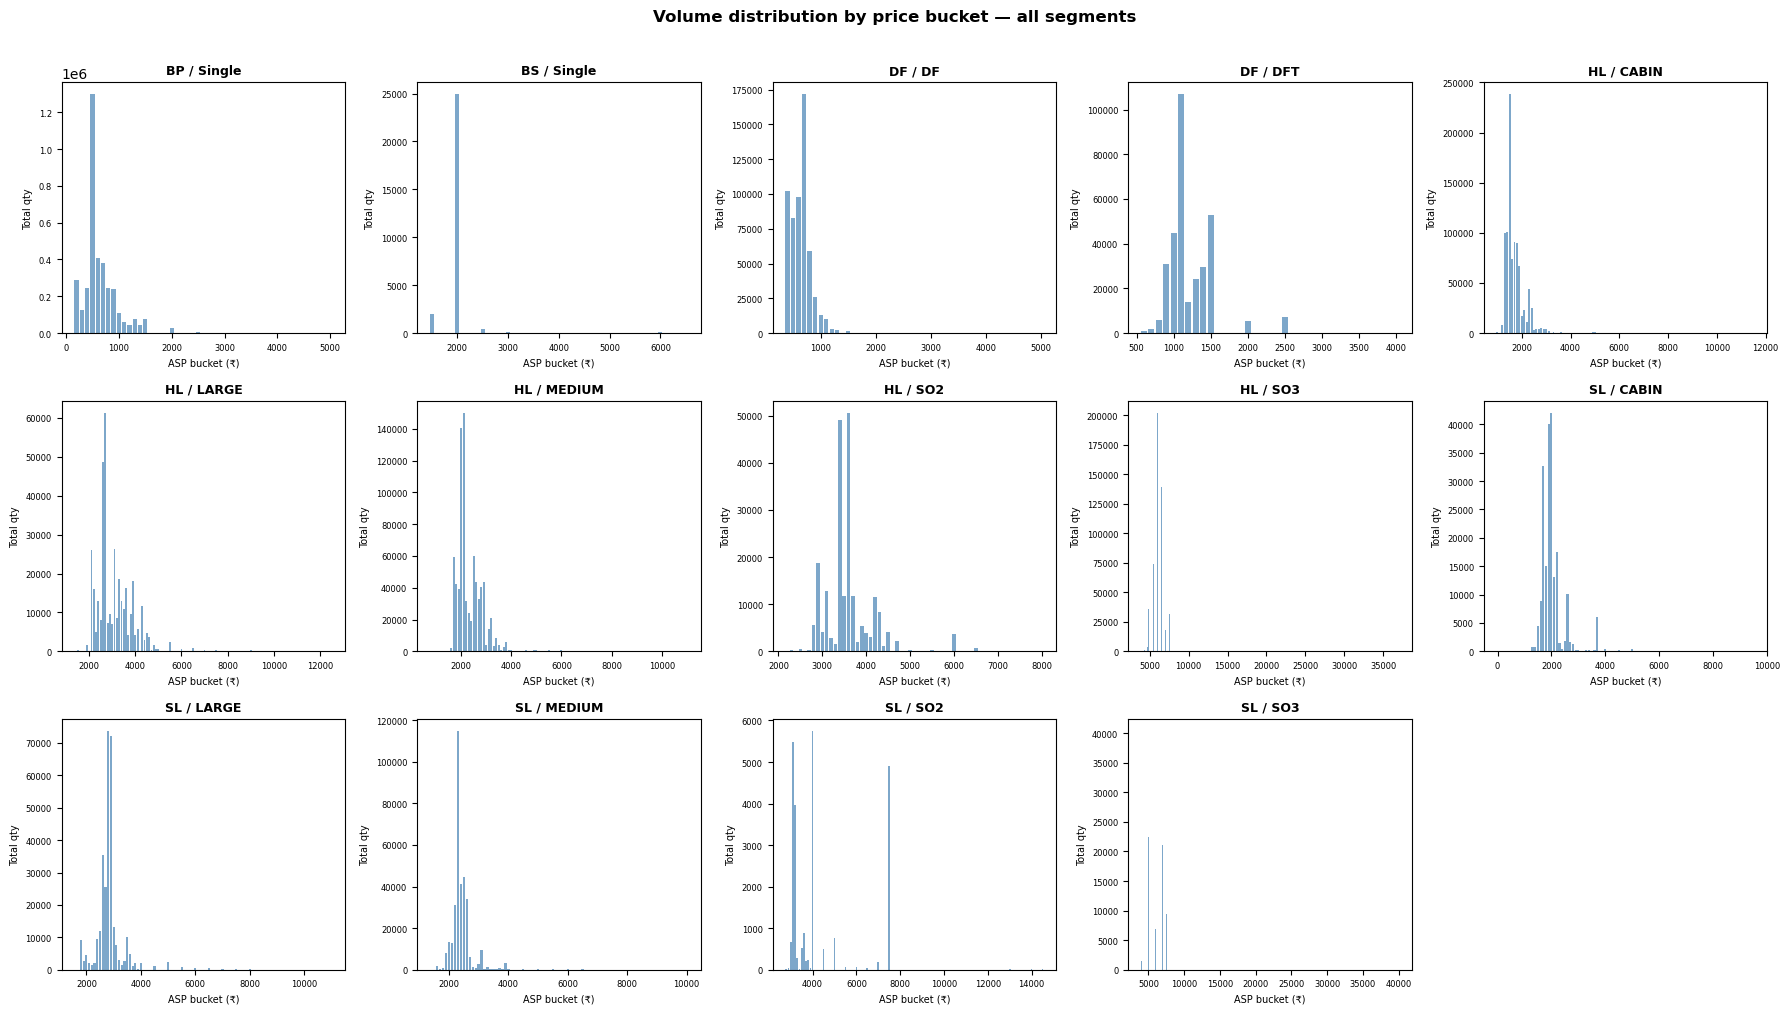

Saved: 02_price_distributions.png


In [20]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

segments = sorted(bucket_ts.groupby(['Division', 'Size']).groups.keys())

for idx, (div, size) in enumerate(segments):
    seg = bucket_ts[(bucket_ts['Division'] == div) & 
                    (bucket_ts['Size'] == size)]
    
    vol_by_bucket = seg.groupby('bucket_min')['qty'].sum()
    
    axes[idx].bar(vol_by_bucket.index, vol_by_bucket.values, 
                  width=80, color='steelblue', alpha=0.7)
    axes[idx].set_title(f'{div} / {size}', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('ASP bucket (₹)', fontsize=7)
    axes[idx].set_ylabel('Total qty', fontsize=7)
    axes[idx].tick_params(labelsize=6)

# Hide the last empty subplot if segments < 15
for idx in range(len(segments), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Volume distribution by price bucket — all segments', 
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs(OUT_PATH, exist_ok=True)
plt.savefig(f'{OUT_PATH}02_price_distributions.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_price_distributions.png")

In [21]:
bucket_ts.to_csv(f'{OUT_PATH}02_fine_bucket_ts.csv', index=False)

print("NOTEBOOK 02 COMPLETE")
print(f"Saved: 02_fine_bucket_ts.csv")
print(f"\nSummary:")
print(f"  Input rows          : 43,905")
print(f"  Grouped range-months: {len(grp):,}")
print(f"  Fine bucket rows    : {len(bucket_ts):,}")
print(f"  Segments ready      : 14")
print(f"\nNext: 03_trend_pivot.ipynb")

NOTEBOOK 02 COMPLETE
Saved: 02_fine_bucket_ts.csv

Summary:
  Input rows          : 43,905
  Grouped range-months: 29,701
  Fine bucket rows    : 13,988
  Segments ready      : 14

Next: 03_trend_pivot.ipynb
